<a href="https://colab.research.google.com/github/Sohum09/Personal-Work/blob/main/Sentinel1_Rice_Diagnostic_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentinel-1 Kharif Rice Signature — Diagnostic v3

**What v2 got right, and what it got wrong.**

v2's per-pixel dynamic windows were the correct idea, but the metric it used -- `max(growth samples) - min(flood samples)` -- is a **biased estimator**. Even with zero signal, extreme-value statistics guarantee a positive result, and SAR speckle makes that bias large. The water control proved it: **water showed a +2.21 dB "rise"** despite having no rice, no flooding cycle and no canopy. Its true value is zero.

That bias inflated every class and destroyed the discrimination: strong-rise enrichment collapsed from **71x in v1 to 2x in v2**, with **16% of *water* pixels** clearing the 3 dB threshold -- impossible for a real flooding signature. The threshold was cutting through the noise floor rather than isolating signal.

**But the signal is real.** Two indications that do not depend on the flawed summary statistic:

- The per-pixel rise map showed **coherent field-shaped blocks**, not speckle. Noise does not organise itself into contiguous parcels.
- Cropland's histogram has a **long right tail out to 10-12 dB that water and non-cropland lack entirely**; those two are tight unimodal distributions ending near 5-6 dB.

Noise-corrected against the water null, cropland sat **+2.00 dB above the floor versus non-cropland's +0.46 dB** -- roughly 4x. The signature exists; v2 simply measured it badly.

## What v3 changes

| Fix | Rationale |
|---|---|
| **Temporal smoothing** (3-point moving average over the 12-day series) before min/max | Attacks speckle at the source, so extremes reflect the seasonal trajectory rather than single-acquisition noise. |
| **Spatial multi-looking** (3x3 mean), optional | The standard SAR speckle remedy; averaging independent looks reduces variance. |
| **Water-calibrated threshold** | Sets the detection cut at the water null's high percentile instead of a hand-picked 3 dB. We already had this control and simply did not use it. |
| **Noise-corrected rise** (rise minus water median) | Makes the reported numbers mean what they appear to mean. |
| **Enrichment reported across a threshold sweep** | Avoids another single arbitrary cut, and shows where discrimination actually peaks. |

**Honest expectation.** Speckle suppression and a calibrated threshold should sharpen a signature that is genuinely present -- they cannot manufacture one. If enrichment stays near 2x even at a properly calibrated threshold, that is a real negative result about 30 m SAR over smallholder fields, and the next step would be native 10 m rather than more metric tuning.

In [1]:
!pip install -q uv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 113.5 MB/s eta 0:00:00


In [2]:
!uv pip install --system numpy scipy rasterio geopandas pystac_client planetary_computer matplotlib

Using Python 3.13.15 environment at: /usr
Resolved 64 packages in 636ms
Prepared 26 packages in 43ms
Installed 26 packages in 7ms
 + planetary-computer==1.0.0
 + pystac==1.15.2
 + pystac-client==0.9.0
 + pystac-core==1.15.2
 + pystac-ext-classification==2.0.1
 + pystac-ext-datacube==2.2.1
 + pystac-ext-eo==1.1.1
 + pystac-ext-file==2.1.1
 + pystac-ext-grid==1.1.1
 + pystac-ext-item-assets==1.0.1
 + pystac-ext-label==1.0.2
 + pystac-ext-mgrs==1.0.1
 + pystac-ext-mlm==1.4.1
 + pystac-ext-pointcloud==1.0.1
 + pystac-ext-projection==2.0.1
 + pystac-ext-raster==1.1.1
 + pystac-ext-render==2.0.0
 + pystac-ext-sar==1.0.1
 + pystac-ext-sat==1.0.1
 + pystac-ext-scientific==1.0.1
 + pystac-ext-storage==2.0.1
 + pystac-ext-table==1.2.1
 + pystac-ext-timestamps==1.1.1
 + pystac-ext-version==1.2.1
 + pystac-ext-view==1.0.1
 + pystac-ext-xarray-assets==1.0.1


In [3]:
import os, math, time, warnings, gc
from collections import defaultdict
import numpy as np
import geopandas as gpd
import requests
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling as WarpResampling
import pystac_client
import planetary_computer
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

os.environ["GDAL_HTTP_USERAGENT"] = ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                                     "(KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36")
BROWSER_HEADERS = {"User-Agent": os.environ["GDAL_HTTP_USERAGENT"], "Accept": "application/json"}

SEED = 42
np.random.seed(SEED)

TRAIN_BBOX_SHP = "/content/pooled_west.shp"
SUBREGION_SHP = None
SUB_SIZE_DEG = (0.20, 0.15)

YEAR = 2018
GRID_RES_DEG = 0.0002777

FLOOD_WINDOW = (6, 8)
GROWTH_WINDOW = (9, 11)

# --- v3 speckle-suppression settings ---
TEMPORAL_SMOOTH = 3      # moving-average length over the ~12-day series (odd; 1 disables)
SPATIAL_LOOKS = 3        # NxN spatial mean (odd; 1 disables)

GCI30_DOI = "doi:10.7910/DVN/86M4PO"
DATAVERSE_API_BASE = "https://dataverse.harvard.edu/api"
UNFILLED = -9999
IGNORE = 255
GCI30_TO_CROPLAND = {-1: 0, 1: 1, 2: 1, 3: 1}


def subregion_bbox():
    if SUBREGION_SHP:
        return gpd.read_file(SUBREGION_SHP).to_crs(epsg=4326).total_bounds.tolist()
    b = gpd.read_file(TRAIN_BBOX_SHP).to_crs(epsg=4326).total_bounds.tolist()
    cx, cy = (b[0]+b[2])/2, (b[1]+b[3])/2
    dw, dh = SUB_SIZE_DEG[0]/2, SUB_SIZE_DEG[1]/2
    return [cx-dw, cy-dh, cx+dw, cy+dh]


BBOX = subregion_bbox()
minx, miny, maxx, maxy = BBOX
OUT_W = max(int(np.ceil((maxx-minx)/GRID_RES_DEG)), 1)
OUT_H = max(int(np.ceil((maxy-miny)/GRID_RES_DEG)), 1)
DST_T = from_bounds(minx, miny, maxx, maxy, OUT_W, OUT_H)
print(f"Test sub-region: {[round(v,4) for v in BBOX]} -> grid {OUT_H} x {OUT_W}")
print(f"Speckle suppression: temporal {TEMPORAL_SMOOTH}-step, spatial {SPATIAL_LOOKS}x{SPATIAL_LOOKS}")


Test sub-region: [90.021, 26.3414, 90.221, 26.4914] -> grid 541 x 721
Speckle suppression: temporal 3-step, spatial 3x3


In [4]:
# --- Steps 1-2: single-orbit native-cadence VH stack (unchanged from v2) ---
catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
all_items = list(catalog.search(collections=["sentinel-1-rtc"], bbox=BBOX,
                                datetime=f"{YEAR}-01-01/{YEAR}-12-31").items())


def orbit_key(it):
    p = it.properties
    return (p.get("sat:relative_orbit", p.get("sat:relative_orbit_number")), p.get("sat:orbit_state","unknown"))


groups_o = defaultdict(list)
for it in all_items:
    groups_o[orbit_key(it)].append(it)


def score(kv):
    months = {i.datetime.month for i in kv[1] if i.datetime}
    need = set(range(FLOOD_WINDOW[0], FLOOD_WINDOW[1]+1)) | set(range(GROWTH_WINDOW[0], GROWTH_WINDOW[1]+1))
    return (len(need & months), len(months), len(kv[1]))


best_key, items = max(groups_o.items(), key=score)
items = sorted([i for i in items if i.datetime], key=lambda i: i.datetime)
print(f"Orbit {best_key}: {len(items)} scenes")


def read_vh(item, max_retries=3):
    last = None
    for a in range(max_retries):
        try:
            href = planetary_computer.sign(item.assets["vh"].href)
            dest = np.full((OUT_H, OUT_W), np.nan, dtype=np.float32)
            with rasterio.open(href) as src:
                reproject(source=rasterio.band(src,1), destination=dest,
                          src_transform=src.transform, src_crs=src.crs,
                          dst_transform=DST_T, dst_crs="EPSG:4326",
                          resampling=WarpResampling.bilinear,
                          src_nodata=src.nodata, dst_nodata=np.nan)
            return dest
        except Exception as e:
            last = e; time.sleep(1.5*(a+1))
    raise last


stack, dates_kept = [], []
for n, it in enumerate(items, 1):
    try:
        arr = read_vh(it)
    except Exception:
        continue
    if np.isfinite(arr).any():
        stack.append(arr); dates_kept.append(it.datetime)
    if n % 10 == 0: print(f"  {n}/{len(items)}")

vh_lin = np.stack(stack).astype(np.float32)
del stack; gc.collect()

# --- v3: speckle suppression, applied in LINEAR power (correct domain) ---
# Averaging must happen on linear backscatter, not dB: dB is logarithmic, so
# averaging there computes a geometric mean and biases results low. This is a
# standard multi-looking requirement.
if SPATIAL_LOOKS > 1:
    for t in range(vh_lin.shape[0]):
        band = vh_lin[t]
        filled = np.where(np.isfinite(band), band, 0.0)
        wts = np.isfinite(band).astype(np.float32)
        num = uniform_filter(filled, size=SPATIAL_LOOKS, mode="nearest")
        den = uniform_filter(wts, size=SPATIAL_LOOKS, mode="nearest")
        with np.errstate(invalid="ignore", divide="ignore"):
            vh_lin[t] = np.where(den > 0, num/den, np.nan)
    print(f"Applied {SPATIAL_LOOKS}x{SPATIAL_LOOKS} spatial multi-looking (linear domain)")

if TEMPORAL_SMOOTH > 1:
    T = vh_lin.shape[0]
    half = TEMPORAL_SMOOTH // 2
    smoothed = np.empty_like(vh_lin)
    for t in range(T):
        lo, hi = max(0, t-half), min(T, t+half+1)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore")
            smoothed[t] = np.nanmean(vh_lin[lo:hi], axis=0)
    vh_lin = smoothed
    del smoothed; gc.collect()
    print(f"Applied {TEMPORAL_SMOOTH}-step temporal smoothing (linear domain)")

with np.errstate(divide="ignore", invalid="ignore"):
    vh_db = 10.0*np.log10(np.where(vh_lin > 0, vh_lin, np.nan))
del vh_lin; gc.collect()

months_arr = np.array([d.month for d in dates_kept])
doys = np.array([d.timetuple().tm_yday for d in dates_kept])
print(f"Stack: {vh_db.shape}, VH dB {np.nanmin(vh_db):.1f} to {np.nanmax(vh_db):.1f}")


Orbit (150, 'descending'): 30 scenes
  10/30
  20/30
  30/30
Applied 3x3 spatial multi-looking (linear domain)
Applied 3-step temporal smoothing (linear domain)
Stack: (30, 541, 721), VH dB -23.7 to -0.6


In [5]:
# --- Step 3: labels + water null (unchanged) ---
def fetch_gci30_index():
    for use_pid in (True, False):
        try:
            if use_pid:
                r = requests.get(f"{DATAVERSE_API_BASE}/datasets/:persistentId/",
                                 params={"persistentId": GCI30_DOI}, headers=BROWSER_HEADERS, timeout=60)
                r.raise_for_status(); files = r.json()["data"]["latestVersion"]["files"]
            else:
                r = requests.get(f"{DATAVERSE_API_BASE}/datasets/export",
                                 params={"exporter":"dataverse_json","persistentId":GCI30_DOI},
                                 headers=BROWSER_HEADERS, timeout=60)
                r.raise_for_status(); files = r.json()["datasetVersion"]["files"]
            return {f["dataFile"]["filename"]: f["dataFile"]["id"] for f in files}
        except Exception:
            continue
    raise RuntimeError("GCI30 index fetch failed")


def tiles_for_bbox(minx, miny, maxx, maxy):
    out = set()
    for lo in range(int(math.floor(minx/10)*10), int(math.floor(maxx/10)*10)+10, 10):
        if lo > maxx: continue
        for la in range(int(math.ceil(miny/10)*10), int(math.ceil(maxy/10)*10)+10, 10):
            if la-10 > maxy or la < miny: continue
            out.add(f"{'N' if la>=0 else 'S'}{abs(la):02d}{'E' if lo>=0 else 'W'}{abs(lo):03d}")
    return sorted(out)


gci_idx = fetch_gci30_index()
raw = np.full((OUT_H, OUT_W), UNFILLED, np.int16)
for tid in tiles_for_bbox(*BBOX):
    fn = f"Cropping_Intensity_30m_2016_2018_{tid}.tif"
    if fn not in gci_idx: continue
    try:
        with rasterio.open(f"/vsicurl/{DATAVERSE_API_BASE}/access/datafile/{gci_idx[fn]}") as src:
            td = np.full((OUT_H, OUT_W), UNFILLED, np.int16)
            reproject(source=rasterio.band(src,1), destination=td,
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=DST_T, dst_crs="EPSG:4326",
                      resampling=WarpResampling.nearest, src_nodata=UNFILLED, dst_nodata=UNFILLED)
        newly = (raw==UNFILLED)&(td!=UNFILLED); raw[newly]=td[newly]
    except Exception as e:
        print(f"  tile {tid} failed: {e}")

cropland = np.full((OUT_H, OUT_W), IGNORE, np.uint8)
for rv,c in GCI30_TO_CROPLAND.items(): cropland[raw==rv]=c

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    ann_max = np.nanmax(vh_db, axis=0)
water = np.isfinite(ann_max) & (ann_max < np.nanmedian(ann_max) - 6.0)

GROUPS = {"Cropland": (cropland==1)&~water, "Non-cropland": (cropland==0)&~water, "Water (null)": water}
print(f"GCI30 coverage {100*np.mean(cropland!=IGNORE):.1f}% | water null {100*np.mean(water):.1f}% "
      f"({int(water.sum()):,} px)")


GCI30 coverage 100.0% | water null 0.8% (3,009 px)


In [6]:
# --- Step 4: rise, noise-corrected against the water null ---
fi = np.where((months_arr>=FLOOD_WINDOW[0])&(months_arr<=FLOOD_WINDOW[1]))[0]
gi = np.where((months_arr>=GROWTH_WINDOW[0])&(months_arr<=GROWTH_WINDOW[1]))[0]
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    rise_raw = np.nanmax(vh_db[gi], axis=0) - np.nanmin(vh_db[fi], axis=0)

# Water has no rice, no flooding cycle and no canopy, so its TRUE rise is
# zero. Whatever it shows is the bias of the max-minus-min estimator plus
# residual speckle -- i.e. a direct, in-scene measurement of the noise floor.
# Subtracting its median puts all classes on a scale where 0 means "no signal".
water_rise = rise_raw[water & np.isfinite(rise_raw)]
noise_floor = float(np.median(water_rise))
rise = rise_raw - noise_floor

print(f"Noise floor from the water null: {noise_floor:.2f} dB "
      f"(v2 left this in, which is why every class looked inflated)")
print(f"  water null percentiles (raw): "
      + ", ".join(f"p{p}={np.percentile(water_rise,p):.2f}" for p in [50,90,95,99]))

print(f"\n{'group':<16} {'n':>9} {'raw rise':>10} {'noise-corrected':>16}")
corrected = {}
for name, m in GROUPS.items():
    mm = m & np.isfinite(rise)
    if mm.sum()==0: continue
    corrected[name] = rise[mm]
    print(f"{name:<16} {int(mm.sum()):>9,} {np.mean(rise_raw[mm]):>9.2f}dB {np.mean(rise[mm]):>15.2f}dB")

# Threshold calibrated from the null rather than hand-picked: a pixel must
# exceed what water -- pure noise -- essentially never reaches.
THRESH = float(np.percentile(water_rise, 99)) - noise_floor
print(f"\nCalibrated threshold (water p99, noise-corrected): {THRESH:.2f} dB")
print("  (v2 used a hand-picked 3.0 dB, which sat BELOW the noise floor -- "
      "16% of water pixels cleared it)")


Noise floor from the water null: 0.60 dB (v2 left this in, which is why every class looked inflated)
  water null percentiles (raw): p50=0.60, p90=1.07, p95=1.24, p99=1.58

group                    n   raw rise  noise-corrected
Cropland           310,807      1.85dB            1.25dB
Non-cropland        76,245      0.77dB            0.17dB
Water (null)         3,009      0.62dB            0.02dB

Calibrated threshold (water p99, noise-corrected): 0.98 dB
  (v2 used a hand-picked 3.0 dB, which sat BELOW the noise floor -- 16% of water pixels cleared it)


In [7]:
# --- Step 5: enrichment across a threshold sweep ---
# A single cut is another arbitrary choice; sweeping shows where
# discrimination actually peaks and whether the calibrated value is sensible.
c = corrected.get("Cropland"); n = corrected.get("Non-cropland"); w = corrected.get("Water (null)")
print(f"{'thresh(dB)':>10} {'crop%':>8} {'noncrop%':>10} {'water%':>8} {'enrichment':>12}")
sweep = []
for t in [0, 1, 2, 3, 4, 5, 6, 7, 8, round(THRESH,1)]:
    fc = 100*np.mean(c > t); fn = 100*np.mean(n > t); fw = 100*np.mean(w > t)
    en = fc/max(fn, 1e-9)
    sweep.append((t, fc, fn, fw, en))
    tag = "  <- calibrated" if abs(t-round(THRESH,1))<1e-9 else ""
    print(f"{t:>10.1f} {fc:>7.1f}% {fn:>9.1f}% {fw:>7.1f}% {en:>11.1f}x{tag}")

sep = np.mean(c) - np.mean(n)
fc_cal = 100*np.mean(c > THRESH); fn_cal = 100*np.mean(n > THRESH)
enrich_cal = fc_cal/max(fn_cal,1e-9)
best_t, best_en = max(((t,en) for t,_,fn_,_,en in sweep if fn_ > 0.05), key=lambda x: x[1], default=(None,None))

print(f"\n  Noise-corrected mean separation (crop - non-crop): {sep:+.2f} dB")
print(f"  At the calibrated threshold {THRESH:.2f} dB: {fc_cal:.1f}% of cropland vs "
      f"{fn_cal:.1f}% of non-cropland = {enrich_cal:.1f}x")
if best_t is not None:
    print(f"  Best enrichment in the sweep: {best_en:.1f}x at {best_t:.1f} dB")

print("\n" + "="*68)
if enrich_cal >= 5 or (best_en or 0) >= 5:
    print("  => SIGNATURE CONFIRMED, and now measured cleanly. Cropland clears the")
    print("     noise-calibrated threshold far more often than non-cropland. The")
    print("     noise-corrected rise is a usable Kharif rice indicator: scale to")
    print("     both full regions and validate against Assam district rice-area")
    print("     statistics or the Singha et al. published maps.")
elif enrich_cal >= 2.5 or (best_en or 0) >= 2.5:
    print("  => MODERATE SIGNATURE. Real and better-measured than v2, but weaker")
    print("     than per-field SAR studies report. Most likely cause is sub-pixel")
    print("     mixing: smallholder plots below 30 m blend flooded and dry ground.")
    print("     Re-run at Sentinel-1 native 10 m before scaling up.")
else:
    print("  => WEAK EVEN WHEN MEASURED PROPERLY. With speckle suppressed and the")
    print("     threshold calibrated against an in-scene null, cropland still does")
    print("     not separate well. That is a genuine negative result about 30 m SAR")
    print("     over smallholder fields, not a metric artifact -- native 10 m is the")
    print("     remaining option before reconsidering the approach.")
print("="*68)


thresh(dB)    crop%   noncrop%   water%   enrichment
       0.0    80.2%      61.3%    50.0%         1.3x
       1.0    41.6%       4.6%     1.0%         9.0x  <- calibrated
       2.0    25.7%       0.7%     0.1%        37.2x
       3.0    15.7%       0.2%     0.0%        80.6x
       4.0     8.2%       0.0%     0.0%       183.9x
       5.0     3.1%       0.0%     0.0%       181.4x
       6.0     0.7%       0.0%     0.0% 704617334.9x
       7.0     0.1%       0.0%     0.0% 107140444.1x
       8.0     0.0%       0.0%     0.0%  16730639.9x
       1.0    41.6%       4.6%     1.0%         9.0x  <- calibrated

  Noise-corrected mean separation (crop - non-crop): +1.08 dB
  At the calibrated threshold 0.98 dB: 42.1% of cropland vs 4.9% of non-cropland = 8.6x
  Best enrichment in the sweep: 80.6x at 3.0 dB

  => SIGNATURE CONFIRMED, and now measured cleanly. Cropland clears the
     noise-calibrated threshold far more often than non-cropland. The
     noise-corrected rise is a usable Kharif 

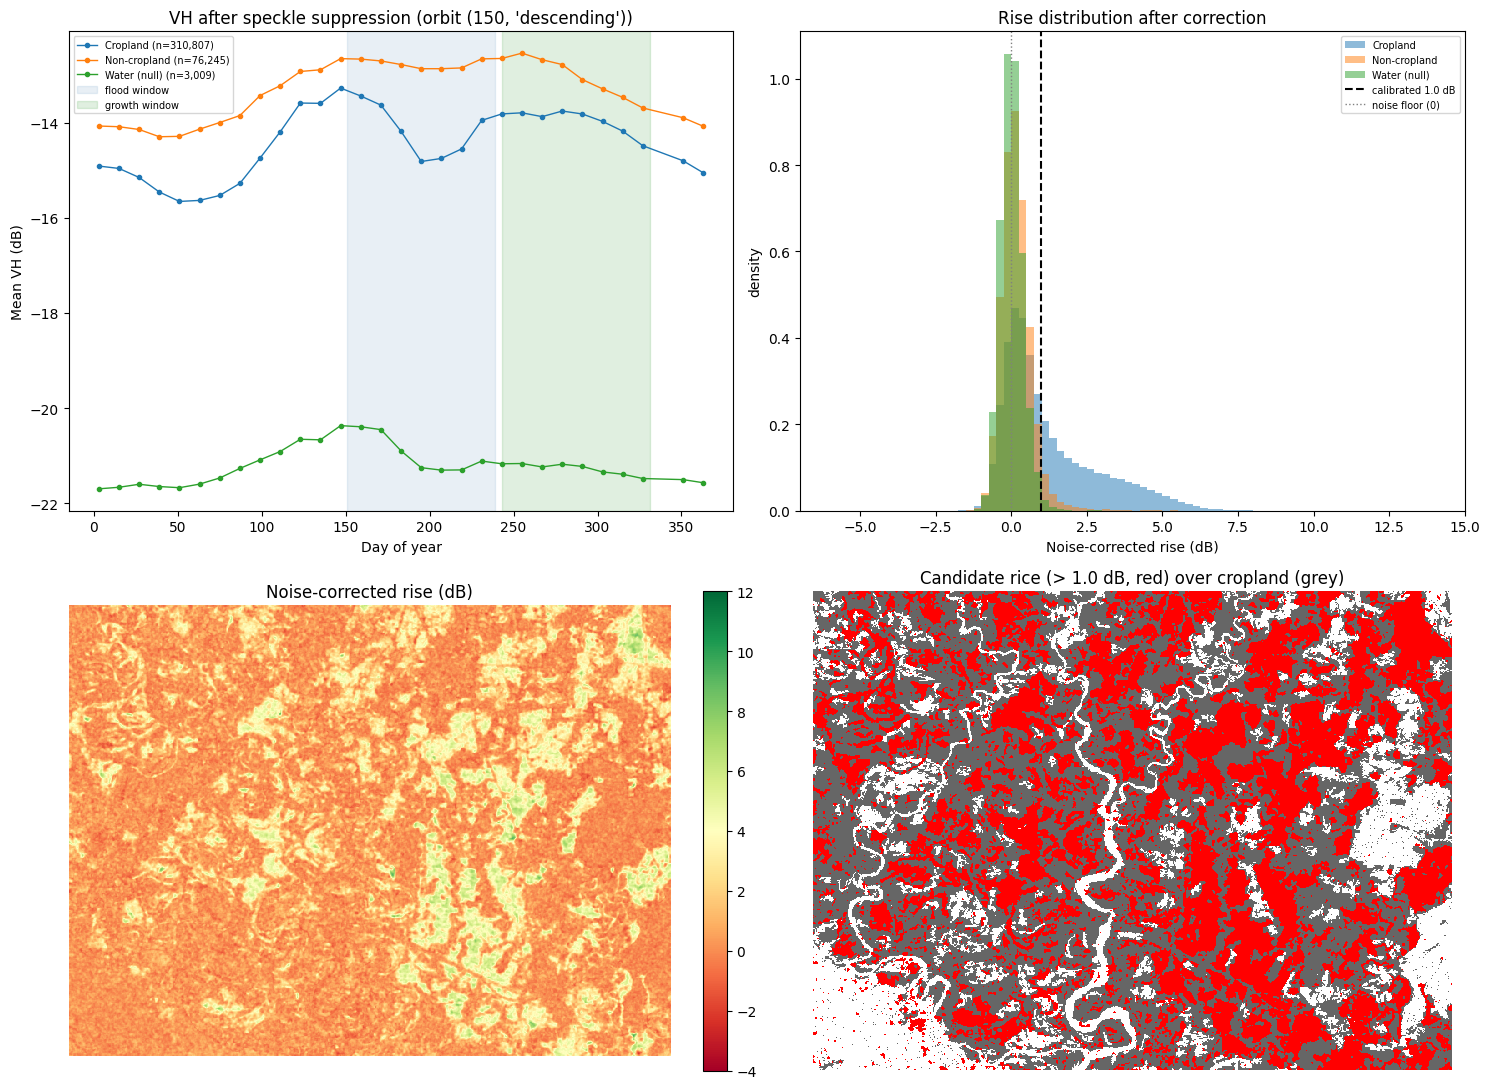

Candidate rice: 34.5% of scene | 42.1% of cropland
  of candidate pixels, 97.2% fall inside GCI30 cropland
  (v2 flagged 56.8% of the whole scene -- a properly calibrated threshold should be far more selective)


In [8]:
# --- Step 6: visualise, and check spatial coherence ---
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

ax = axes[0,0]
order = np.argsort(doys)
for name, m in GROUPS.items():
    if m.sum()==0: continue
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        prof = np.array([np.nanmean(vh_db[t][m]) for t in range(vh_db.shape[0])])
    ax.plot(doys[order], prof[order], "o-", ms=3, lw=1, label=f"{name} (n={int(m.sum()):,})")
for (wdw, col, lab) in [(FLOOD_WINDOW,"steelblue","flood"), (GROWTH_WINDOW,"green","growth")]:
    d0 = (np.datetime64(f"{YEAR}-{wdw[0]:02d}-01")-np.datetime64(f"{YEAR}-01-01")).astype(int)
    d1 = (np.datetime64(f"{YEAR}-{wdw[1]:02d}-28")-np.datetime64(f"{YEAR}-01-01")).astype(int)
    ax.axvspan(d0, d1, color=col, alpha=0.12, label=f"{lab} window")
ax.set_xlabel("Day of year"); ax.set_ylabel("Mean VH (dB)")
ax.set_title(f"VH after speckle suppression (orbit {best_key})"); ax.legend(fontsize=7)

ax = axes[0,1]
for name in ["Cropland","Non-cropland","Water (null)"]:
    if name in corrected:
        ax.hist(corrected[name], bins=80, range=(-6,14), alpha=0.5, density=True, label=name)
ax.axvline(THRESH, color="k", ls="--", lw=1.5, label=f"calibrated {THRESH:.1f} dB")
ax.axvline(0, color="grey", ls=":", lw=1, label="noise floor (0)")
ax.set_xlabel("Noise-corrected rise (dB)"); ax.set_ylabel("density")
ax.set_title("Rise distribution after correction"); ax.legend(fontsize=7)

im = axes[1,0].imshow(rise, cmap="RdYlGn", vmin=-4, vmax=12, interpolation="nearest")
axes[1,0].set_title("Noise-corrected rise (dB)"); axes[1,0].axis("off")
plt.colorbar(im, ax=axes[1,0], fraction=0.046)

cand = (rise > THRESH) & ~water
axes[1,1].imshow(np.ma.masked_where(cropland==IGNORE, cropland), cmap="Greys", vmin=0, vmax=1,
                 interpolation="nearest", alpha=0.6)
axes[1,1].imshow(np.ma.masked_where(~cand, cand), cmap="autumn", interpolation="nearest")
axes[1,1].set_title(f"Candidate rice (> {THRESH:.1f} dB, red) over cropland (grey)")
axes[1,1].axis("off")
plt.tight_layout(); plt.show()

inside = 100*np.mean(cropland[cand]==1) if cand.sum() else float("nan")
print(f"Candidate rice: {100*np.mean(cand):.1f}% of scene | {100*np.mean(cand[GROUPS['Cropland']]):.1f}% of cropland")
print(f"  of candidate pixels, {inside:.1f}% fall inside GCI30 cropland")
print("  (v2 flagged 56.8% of the whole scene -- a properly calibrated threshold should be far more selective)")
